# Probit Model


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from arviz import convert_to_inference_data, summary
from scipy.linalg import inv, solve
from scipy.stats import gaussian_kde, norm
from tqdm import trange
rng = np.random.default_rng(seed=99)

In [2]:
def mcmc_stats(runs, burnin=0, chain=4, prob=0.95, param_string=None, isvariance=True):
    """
    Posterior statistics

    Inputs
    runs         --- Monte Carlo sample
    burnin       --- the number of runs in the burnin stage
    chain        --- the number of chains used for convergence diagnostics
    prob         --- the posterior probability for interval estimation
    param_string --- the list of parameter names
    isvariance   ---- True if the variance is included

    Outputs
    posterior_statistics ---  table of posterior statistics (Pandas datafarme)
    """
    if runs.shape[0] < burnin:
        raise ValueError('You need to reduce the number of draws to be discarded as burnin.')
    draw = (runs.shape[0] - burnin) // chain
    if runs.shape[0] != burnin + draw * chain:
        raise ValueError('The number of draws must be divided by the number of chains.')
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    traces = convert_to_inference_data(np.stack([runs[burnin:, i].reshape((chain, draw)) \
                                                 for i in range(runs.shape[1])], axis=2))
    posterior_statistics = summary(traces, hdi_prob=prob)
    posterior_statistics.index = param_string
    return posterior_statistics

In [3]:
def mcmc_plots(runs, burnin=0, param_string=None, isvariance=True):
    """
    Posterior plots

    Inputs
    runs          --- Monte Carlo sample
    burnin        --- the number of runs in the burnin stage
    isvariance   ---- True if the variance is included

    Outputs
    kde_x         --- grid
    kde_posterior --- kernel density estimation
    """
    grid = 250
    k = runs.shape[1]
    kde_x = np.zeros((grid, k))
    kde_posterior = np.zeros((grid, k))
    if isvariance:
        num_b = k - 1
    else:
        num_b = k
    if not param_string:
        if isvariance:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1]-1)]
            param_string.append('$\\sigma^{2}$')
        else:
            param_string = [f'$\\beta_{i}$' for i in range(runs.shape[1])]
    fig, ax = plt.subplots(k, 2, num=1, figsize=(8, 1.5*k), facecolor='w')
    for index in range(k):
        mc_trace = runs[burnin:, index]
        if index < num_b:
            x_min = mc_trace.min() - 0.2 * np.abs(mc_trace.min())
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        else:
            x_min = 0.0
            x_max = mc_trace.max() + 0.2 * np.abs(mc_trace.max())
            x = np.linspace(x_min, x_max, grid)
            y_label = param_string[index]
        posterior = gaussian_kde(mc_trace).evaluate(x)
        ax[index, 0].plot(mc_trace, linewidth=0.1)
        ax[index, 0].set_xlim(1, draws)
        ax[index, 0].set_ylabel(y_label)
        ax[index, 1].plot(x, posterior)
        ax[index, 1].set_xlim(x_min, x_max)
        ax[index, 1].set_ylim(0, 1.1*posterior.max())
        ax[index, 1].set_ylabel('Density')
        kde_x[:, index] = x
        kde_posterior[:, index] = posterior
    ax[-1, 0].set_xlabel('Random Sequence')
    ax[-1, 1].set_xlabel('Posterior Distribution')
    plt.tight_layout()
    plt.show
    return kde_x, kde_posterior

## Binary choice model

$$
    y_{i} = \begin{cases}
                1, & \text{with probability } q_{i}; \\
                0, & \text{with probability } 1-q_{i}.
            \end{cases}
$$

where

$$
    q_{i} = F(x_{i}^{\intercal}\beta)
          = \begin{cases}
                \int_{-\infty}^{x_{i}^{\intercal}\beta}\frac1{\sqrt{2\pi}}e^{-\frac{z^{2}}{2}}dz, & \text{probit model}; \\
                \frac{e^{x_{i}^{\intercal}\beta}}{1+e^{x_{i}^{\intercal}\beta}}, & \text{logit model}. \\
    \end{cases}
$$


## Gibbs sampler for the probit model

+ The full conditional posterior distribution of $\beta$ given $z=[z_{1};\dots;z_{n}]$ is

$$
    \beta|z,D\sim \mathrm{Normal}(\beta_{\star},\Sigma_{\star}),
$$

where

$$
    \beta_{\star} = (X^{\intercal}X + A_{0})^{-1}(X^{\intercal}z+A_{0}\beta_{0}),\quad \Sigma_{\star} = (X^{\intercal}X + A_{0})^{-1}.
$$

+ The full conditional posterior distribution of $z_{i}$ ($i=1,\dots,n$) given $\beta$ is

$$
    z_{i}|\beta,D \sim
    \begin{cases}
      \mathrm{Normal}^{+}(x_{i}^{\intercal}\beta, 1), & \text{if } y_{i} = 1; \\
      \mathrm{Normal}^{-}(x_{i}^{\intercal}\beta, 1), & \text{if } y_{i} = 0,
    \end{cases}
$$


In [4]:
def gibbs_probit(y, X,  hyper_param, burnin=1000, draws=10000, rng=None):
    """
    Gibbs sampler for logit model

    Inputs
    y       --- regressand (n x 1)
    X       --- regressors (n x k)
    hyper_param = [b0, A0]
    b0      --- the prior mean vector of the regression coefficients
    A0      --- the prior precision matrix of the regression coefficients
    burnin  --- the number of runs in the burnin stage
    draws   --- the number of runs in the sampling stage
    rng     --- the initial state of the random number generator

    Outputs
    runs    --- Monte Carlo sample ((burnin + draws) x k)
    """
    if rng == None:
        rng = np.random.default_rng(seed=1234)
    iterations = burnin + draws
    b0, A0 = hyper_param
    n, k = X.shape
    positive = (y > 0.0)
    negative = (y < 0.0)
    choose = np.eye(k, dtype=bool)
    XX = X.T @ X
    cov_b = inv(XX)
    b = solve(XX, X.T @ y)
    z = np.empty(n)
    runs = np.empty((iterations, k))
    for it in trange(iterations):
        mu = X @ b
        mu_positive = mu[positive]
        prob_positive = 1.0 - norm.sf(0.0, loc=mu_positive)
        z[positive] = norm.ppf(rng.uniform(low=prob_positive), loc=mu_positive)
        mu_negative = mu[negative]
        prob_negative = norm.cdf(0.0, loc=mu_negative)
        z[negative] = norm.ppf(rng.uniform(high=prob_negative), loc=mu_negative)
        b = rng.multivariate_normal(solve(XX, X.T @ z), cov_b)
        runs[it, :] = b
    return runs

In [5]:
n = 500
x1 = rng.uniform(low=-np.sqrt(3.0), high=np.sqrt(3.0), size=n)
x2 = rng.uniform(low=-np.sqrt(3.0), high=np.sqrt(3.0), size=n)
q = norm.cdf(0.5*x1 - 0.5*x2)
y = rng.binomial(1, q)
X = np.stack((np.ones(n), x1, x2), axis=1)
n, k = X.shape
b0 = np.zeros(k)
A0 = 0.01 * np.eye(k)
hyper_param = [b0, A0]

## Gibbs sampler


In [6]:
burnin = 5000
draws = 20000
runs_gibbs = gibbs_probit(y, X, hyper_param, burnin=burnin, draws=draws, rng=rng)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 25000/25000 [00:04<00:00, 5284.55it/s]


In [7]:
results_gibbs = mcmc_stats(runs_gibbs, burnin=burnin, isvariance=False)
display(results_gibbs)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\beta_0$,0.865,0.056,0.757,0.975,0.001,0.0,9168.0,14124.0,1.0
$\beta_1$,0.179,0.056,0.070,0.288,0.001,0.0,9325.0,14844.0,1.0
$\beta_2$,-0.183,0.056,-0.295,-0.074,0.001,0.0,9698.0,14595.0,1.0


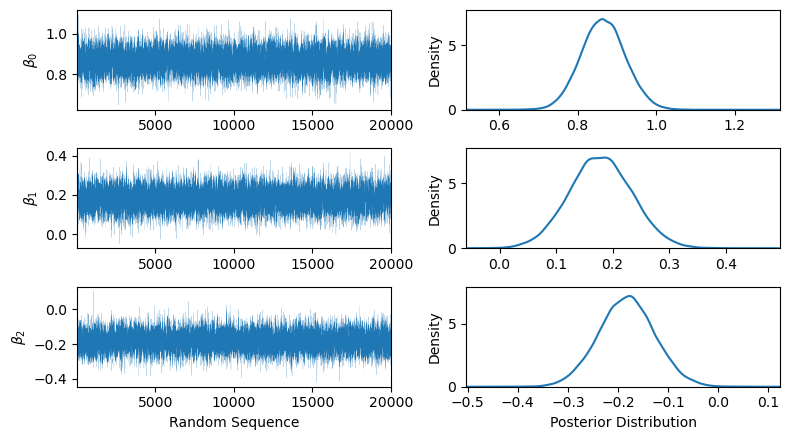

In [8]:
_ = mcmc_plots(runs_gibbs, burnin=burnin, isvariance=False)

## Implementation with PyMC


In [9]:
probit_model = pm.Model()
with probit_model:
    b = pm.MvNormal('b', mu=b0, tau=A0, shape=k)
    idx = X @ b
    likelihood = pm.Bernoulli('y', p=pm.invprobit(idx), observed=y)

In [10]:
n_draws = 5000
n_chains = 4
n_tune = 5000
with probit_model:
    trace = pm.sample(draws=n_draws, chains=n_chains, tune=n_tune, target_accept=0.9, random_seed=rng)
runs_pymc = np.vstack([trace.posterior['b'].to_numpy()[:, :, index].flatten() for index in range(k)]).T

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [b]


Output()

Sampling 4 chains for 5_000 tune and 5_000 draw iterations (20_000 + 20_000 draws total) took 4 seconds.


In [11]:
results_pymc = mcmc_stats(runs_pymc, isvariance=False)
display(results_pymc)

,mean,sd,hdi_2.5%,hdi_97.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\beta_0$,0.050,0.060,-0.068,0.167,0.0,0.0,18869.0,15441.0,1.0
$\beta_1$,0.464,0.064,0.340,0.593,0.0,0.0,18759.0,14575.0,1.0
$\beta_2$,-0.512,0.064,-0.636,-0.384,0.0,0.0,19922.0,16372.0,1.0


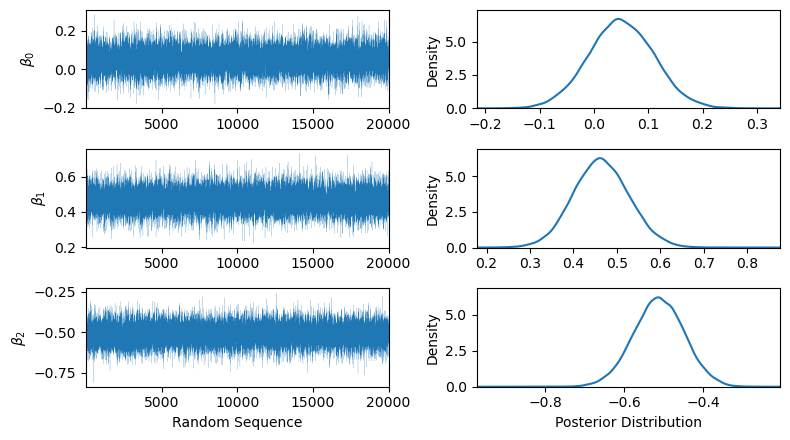

In [12]:
_ = mcmc_plots(runs_pymc, isvariance=False)